In [58]:
##Package installs (if you have never done so)

# !pip install pandas
# !pip install gspread
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn
# !pip install scipy
# !pip install scikit-posthocs
# !pip install numpy

In [50]:
#Google Sheets Linking (Needs user authorization)
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [51]:
import pandas as pd

# Open the spreadsheet by URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/14pMQzQwy2Dl9OIhS24hyJdX1sfEdVi9SeZfGuYaMKQ0/edit?usp=drive_link'
wb = gc.open_by_url(spreadsheet_url)
sheet = wb.get_worksheet(0)

# Load data into DataFrame
data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

print("Sanity Check - Original Data:")
display(df.head())

Sanity Check - Original Data:


,text,label
0,Hi\n\n\t\tI am running the IR test program fro...,human_legit
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit
4,Kindly suggest changes\n\n--------------------...,human_legit


# Overall Task - EDA
Perform feature engineering on the DataFrame `df` by creating new columns for `word_count`, `link_count`, `capital_char_count`, and `special_char_count` derived from the `text` column. Group the data by `label` to calculate and display the average for these new features. Visualise the distributions of `word_count`, `capital_char_count`, and `special_char_count` using violin plots stratified by `label`, and identify the most frequent words within each label group. Finally, summarize the key findings from this exploratory analysis.

## Feature Engineering

### Subtask:
Create new feature columns for word count, link count, capital letter count, and special character count derived from the text data.

### Filtering:
Remove extreme outlier data points above the 97th percentile for word_count, capital_char_count, and special_char_count

**Reasoning**:
Import the `re` module and create new feature columns (`word_count`, `link_count`, `capital_char_count`, `special_char_count`) based on the `text` column as requested. Filter outliers that skew data. Finally, display the first few rows to verify the changes.



In [52]:
import re

# Function to count links using regex
def count_links(text):
    return len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', str(text)))

# Create new features
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['link_count'] = df['text'].apply(count_links)
df['capital_char_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['special_char_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if not c.isalnum() and not c.isspace()))

# Filter out top 5% outliers for the specified features
features_to_filter = ['word_count', 'capital_char_count', 'special_char_count']

for feature in features_to_filter:
    upper_bound = df[feature].quantile(0.97) #filtering
    df = df[df[feature] <= upper_bound]

# Display the dataframe with new features
print("DataFrame after filtering outliers:")
display(df.head())

DataFrame after filtering outliers:


,text,label,word_count,link_count,capital_char_count,special_char_count
0,Hi\n\n\t\tI am running the IR test program fro...,human_legit,40,0,15,4
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,114,0,21,22
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,49,0,21,10
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,559,1,169,262
4,Kindly suggest changes\n\n--------------------...,human_legit,22,0,14,53


## Statistical Summary

### Subtask:
Group the data by `label` and calculate the average for `word_count`, `link_count`, `capital_char_count`, and `special_char_count`. Display these averages.


**Reasoning**:
Group the DataFrame by 'label' and calculate the mean for the specified feature columns to provide a statistical summary.



In [53]:
# Group by label and calculate averages for the new features
feature_cols = ['word_count', 'link_count', 'capital_char_count', 'special_char_count']
avg_features_by_label = df.groupby('label')[feature_cols].mean()

print("Average Feature Values by Label:")
display(avg_features_by_label)

Average Feature Values by Label:


,word_count,link_count,capital_char_count,special_char_count
label,,,,
human_legit,166.638268,1.103352,49.210894,99.061453
human_phishing,110.076923,0.174145,43.010684,34.174145
llm_legit,96.757000,0.936000,18.713000,23.907000
llm_phishing,97.836000,0.859000,16.788000,17.295000


## Generate Violin Plots

### Subtask:
Visualize the distributions of 'word_count', 'capital_char_count', and 'special_char_count' grouped by 'label' using violin plots.


**Reasoning**:
Import seaborn and matplotlib, then create violin plots for 'word_count', 'capital_char_count', and 'special_char_count' grouped by 'label' to visualize their distributions.



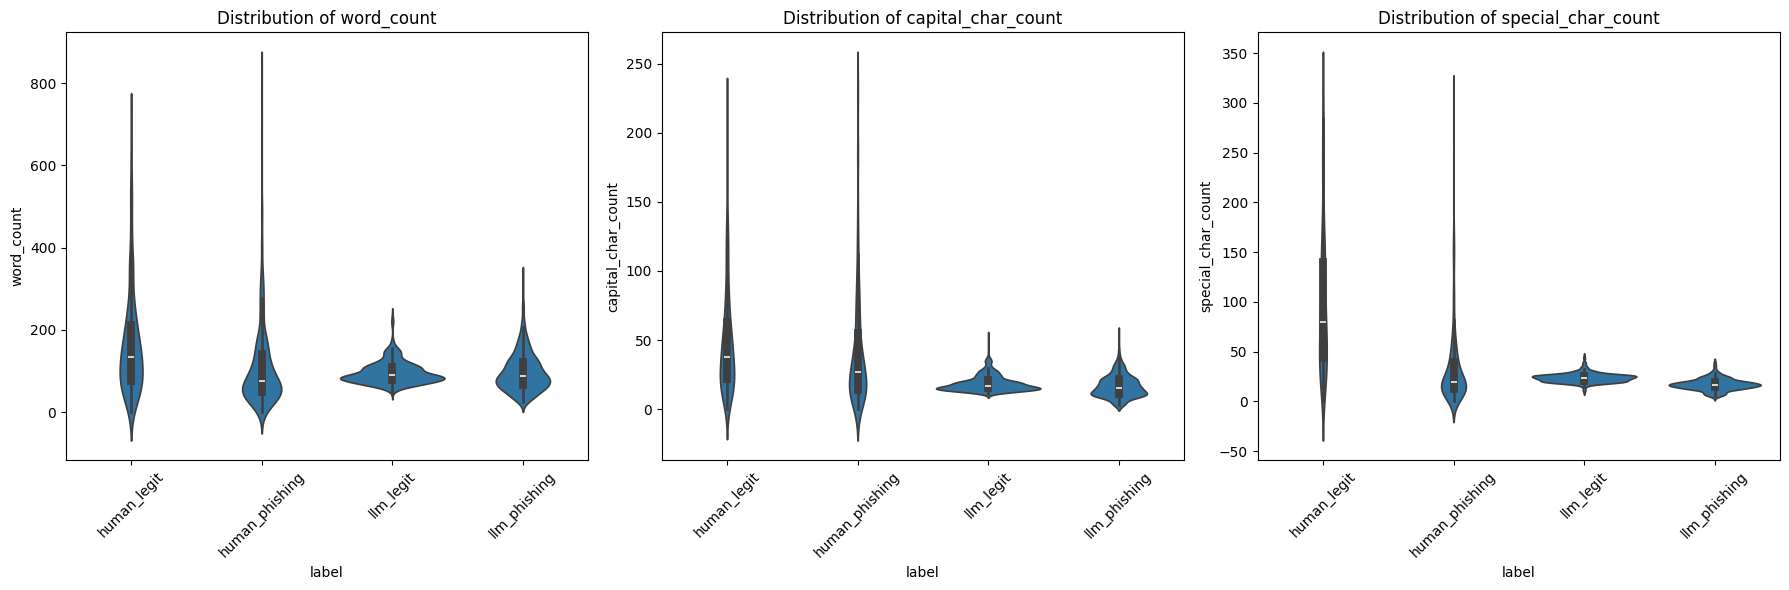

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

features_to_plot = ['word_count', 'capital_char_count', 'special_char_count']

# Generate violin plots for each feature
for i, feature in enumerate(features_to_plot):
    sns.violinplot(x='label', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Statistical Analysis

### Subtask:
Perform Kruskal-Wallis H test to check for overall significance across `label` groups. Follow up with Dunn's post-hoc test using Bonferroni correction for pairwise comparisons. Display the p-values for both tests. Finally, summarize the statistical findings, identifying which features show significant differences between the label groups. p-val = 0.05


In [55]:
def highlight_custom(data):
    # Initialize a DataFrame with 'background-color: red' for all non-significant cells
    # We start with red as the default for "not significant"
    styles = pd.DataFrame('background-color: red', index=data.index, columns=data.columns)

    # 1. Highlight Significant (p < 0.05) as transparent
    is_significant = data < 0.05
    styles[is_significant] = 'background-color: transparent'

    # 2. Highlight Diagonal (Top-Left to Bottom-Right) as Gray
    # We use np.eye to create a boolean mask for the diagonal
    diag_mask = np.eye(len(data), dtype=bool)
    styles.iloc[diag_mask] = 'background-color: gray'

    return styles

for feature in features_to_test:
    print(f"--- Statistical Analysis for {feature} ---")

    # Kruskal-Wallis Test
    groups = [group[feature].values for name, group in df.groupby('label')]
    h_stat, p_val = stats.kruskal(*groups)
    print(f"Kruskal-Wallis H Test: p-value = {p_val:.4e}")

    # Dunn's Post-hoc Test
    dunn_results = sp.posthoc_dunn(df, val_col=feature, group_col='label', p_adjust='bonferroni')

    # Apply the new highlighting
    display(dunn_results.style.apply(highlight_custom, axis=None))
    print("\n")

--- Statistical Analysis for word_count ---
Kruskal-Wallis H Test: p-value = 1.6533e-46


,human_legit,human_phishing,llm_legit,llm_phishing
human_legit,1.000000,0.000000,0.000000,0.000000
human_phishing,0.000000,1.000000,0.000001,0.010941
llm_legit,0.000000,0.000001,1.000000,0.228049
llm_phishing,0.000000,0.010941,0.228049,1.000000




--- Statistical Analysis for link_count ---
Kruskal-Wallis H Test: p-value = 2.0721e-278


,human_legit,human_phishing,llm_legit,llm_phishing
human_legit,1.000000,0.000000,0.000000,0.000000
human_phishing,0.000000,1.000000,0.000000,0.000000
llm_legit,0.000000,0.000000,1.000000,0.007748
llm_phishing,0.000000,0.000000,0.007748,1.000000




--- Statistical Analysis for capital_char_count ---
Kruskal-Wallis H Test: p-value = 2.4163e-144


,human_legit,human_phishing,llm_legit,llm_phishing
human_legit,1.000000,0.000000,0.000000,0.000000
human_phishing,0.000000,1.000000,0.000000,0.000000
llm_legit,0.000000,0.000000,1.000000,0.000000
llm_phishing,0.000000,0.000000,0.000000,1.000000




--- Statistical Analysis for special_char_count ---
Kruskal-Wallis H Test: p-value = 2.2178e-283


,human_legit,human_phishing,llm_legit,llm_phishing
human_legit,1.000000,0.000000,0.000000,0.000000
human_phishing,0.000000,1.000000,0.000000,0.000000
llm_legit,0.000000,0.000000,1.000000,0.000000
llm_phishing,0.000000,0.000000,0.000000,1.000000


### Data Analysis Key Findings
- The Kruskal-Wallis H test confirmed that all selected features have significantly different distributions across the label groups ($p < 0.05$).
- **`special_char_count`** and **`link_count`** demonstrated the most substantial differences among groups, with H-statistics of approximately **1308.40** and **1285.49**, respectively ($p \approx 0$).
- **`capital_char_count`** also showed strong significance across all groups ($H \approx 667.43$).
- While **`word_count`** was significant overall ($H \approx 215.76$), Dunn's post-hoc test revealed that there is **no statistically significant difference** specifically between the `llm_legit` and `llm_phishing` groups ($p \approx 0.228$).

### Insights or Next Steps
- The lack of significant difference in `word_count` between `llm_legit` and `llm_phishing` suggests that Large Language Models generate text of similar length regardless of whether the intent is legitimate or malicious.
- Structural features like `link_count` and `special_char_count` appear to be strong differentiators for classification tasks given their extremely high test statistics compared to word count.


## Word Frequency Analysis

### Subtask:
Analyze the text to find the most popular words for each label by tokenizing and counting frequencies.




**Reasoning**:
Import CountVectorizer, iterate through each unique label to filter the data, compute word frequencies using CountVectorizer (removing English stop words), and display the top 10 most frequent words for each label.



In [56]:
from sklearn.feature_extraction.text import CountVectorizer

# Get unique labels
unique_labels = df['label'].unique()

for label in unique_labels:
    # Filter data for the current label
    subset = df[df['label'] == label]

    # Initialize CountVectorizer
    # Using stop_words='english' to remove common words
    vectorizer = CountVectorizer(stop_words='english')

    try:
        # Fit and transform the text data (ensuring it's string format)
        X = vectorizer.fit_transform(subset['text'].astype(str))

        # Sum frequencies
        word_counts = X.sum(axis=0)

        # Map words to counts
        words = vectorizer.get_feature_names_out()
        counts = word_counts.tolist()[0]

        # Create DataFrame
        word_freq_df = pd.DataFrame({'word': words, 'count': counts})

        # Sort and display top 10
        top_10_words = word_freq_df.sort_values(by='count', ascending=False).head(10)

        print(f"Top 10 words for label '{label}':")
        display(top_10_words)
        print("-" * 30)

    except ValueError as e:
        # Handle cases where vocabulary might be empty
        print(f"Could not process words for label '{label}': {e}")
        print("-" * 30)

Top 10 words for label 'human_legit':


,word,count
5911,org,715
4198,http,710
5137,mail,556
9052,wrote,475
2145,com,429
4982,list,370
259,2008,357
9058,www,356
8602,use,276
7644,spambayes,271


------------------------------
Top 10 words for label 'human_phishing':


,word,count
2690,monkey,1586
2935,org,1514
602,account,1398
1649,email,1202
2323,jose,1196
4090,update,578
2197,information,566
2625,message,526
2527,mail,520
1424,dear,462


------------------------------
Top 10 words for label 'llm_legit':


,word,count
757,dear,1000
533,com,960
1498,https,936
2498,regards,919
50,account,850
1236,finds,796
979,email,793
2726,security,706
1483,hope,664
3042,thank,615


------------------------------
Top 10 words for label 'llm_phishing':


,word,count
2533,link,1210
125,account,1049
805,com,969
2111,https,886
1144,dear,799
3508,regards,679
1412,email,625
2081,hope,599
767,click,554
4184,support,539


------------------------------
